In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# index 0 dành cho padding — quy ước phổ biến.
vocab = {'': 0, 'I': 1, 'like': 2, 'love': 3, 'music': 4, 'movies': 5,
         'not': 6, 'sad': 7, 'happy': 8, 'hate': 9, 'rain': 10, 'sun': 11}

train = [
    ([1, 2, 4],     1),  # "I like music"     → tích cực
    ([1, 3, 5],     1),  # "I love movies"    → tích cực
    ([1, 2, 8],     1),  # "I like happy"     → tích cực
    ([1, 9, 10],    0),  # "I hate rain"      → tiêu cực
    ([1, 6, 2, 7],  0),  # "I not like sad"   → tiêu cực
    ([1, 9, 7],     0),  # "I hate sad"       → tiêu cực
]

def to_tensors(pairs):
    seqs = [torch.tensor(s, dtype=torch.long) for s, _ in pairs]
    labels = torch.tensor([l for _, l in pairs], dtype=torch.long)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    padded = pad_sequence(seqs, batch_first=True, padding_value=0)   # (batch, max_len)
    return padded, labels, lengths

X_train, y_train, lens_train = to_tensors(train)
print('Padded shape:', X_train.shape)
print('Sequence lengths:', lens_train.tolist())
print(X_train)

Padded shape: torch.Size([6, 4])
Sequence lengths: [3, 3, 3, 3, 4, 3]
tensor([[ 1,  2,  4,  0],
        [ 1,  3,  5,  0],
        [ 1,  2,  8,  0],
        [ 1,  9, 10,  0],
        [ 1,  6,  2,  7],
        [ 1,  9,  7,  0]])


In [3]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        # padding_idx=0 → embedding của token  bị đóng băng = 0, không bị update.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)                        # (B, T, E)
        # pack_padded_sequence: bỏ qua các bước padding khi LSTM tính toán → nhanh và đúng.
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)                     # h_n: (1, B, H)
        return self.fc(h_n.squeeze(0))                      # logits (B, num_classes)

model = SentimentLSTM(vocab_size=len(vocab), embed_dim=8, hidden_dim=16, num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

Epoch  20  loss = 0.0000
Epoch  40  loss = 0.0000
Epoch  60  loss = 0.0000
Epoch  80  loss = 0.0000
Epoch 100  loss = 0.0000


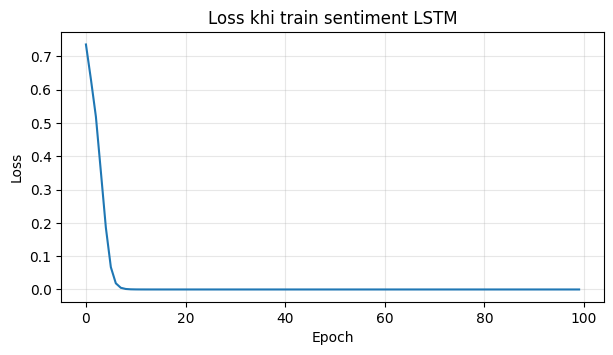

In [4]:
X_train, y_train = X_train.to(device), y_train.to(device)
loss_history = []
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train, lens_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}  loss = {loss.item():.4f}')

plt.figure(figsize=(7, 3.5))
plt.plot(loss_history); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)
plt.title('Loss khi train sentiment LSTM'); plt.show()

In [5]:
# Test trên câu KHÔNG có trong tập train.
test_sentences = [
    'I like sun',          # mong là tích cực
    'I hate movies',       # mong là tiêu cực
    'I love music',        # mong là tích cực
    'I not love rain',     # khó — "not" + "love" + "rain"
]

def predict(sentence):
    tokens = [vocab[w] for w in sentence.split() if w in vocab]
    if not tokens:
        return None
    seq = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)
    length = torch.tensor([len(tokens)])
    model.eval()
    with torch.no_grad():
        logits = model(seq, length)
        proba = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    return proba

for s in test_sentences:
    p = predict(s)
    label = 'Tích cực' if p[1] > 0.5 else 'Tiêu cực'
    print(f'"{s:25s}"  →  {label}  (P_pos={p[1]:.2f})')

"I like sun               "  →  Tích cực  (P_pos=1.00)
"I hate movies            "  →  Tiêu cực  (P_pos=0.00)
"I love music             "  →  Tích cực  (P_pos=1.00)
"I not love rain          "  →  Tiêu cực  (P_pos=0.00)


In [6]:
def make_long_dependency_data(n_samples=500, seq_len=30, n_noise_tokens=8):
    # Sinh dữ liệu mà nhãn phụ thuộc vào ký tự đầu tiên, các bước giữa là nhiễu.
    # Token 0 hoặc 1: signal. Token 2..n_noise_tokens+1: noise.
    X, y = [], []
    for _ in range(n_samples):
        signal = np.random.randint(0, 2)            # 0 hoặc 1
        noise = np.random.randint(2, 2 + n_noise_tokens, size=seq_len - 1)
        seq = np.concatenate([[signal], noise])
        X.append(seq); y.append(signal)
    return torch.tensor(np.array(X), dtype=torch.long), torch.tensor(y, dtype=torch.long)

Xs_train, ys_train = make_long_dependency_data(800)
Xs_test,  ys_test  = make_long_dependency_data(200)
print('train shape:', Xs_train.shape, ' test shape:', Xs_test.shape)
print('Ví dụ một chuỗi:', Xs_train[0].tolist(), '   nhãn:', ys_train[0].item())

train shape: torch.Size([800, 30])  test shape: torch.Size([200, 30])
Ví dụ một chuỗi: [0, 5, 6, 8, 4, 9, 6, 6, 8, 3, 4, 8, 4, 4, 9, 6, 5, 9, 9, 4, 7, 6, 3, 9, 5, 7, 7, 3, 9, 5]    nhãn: 0


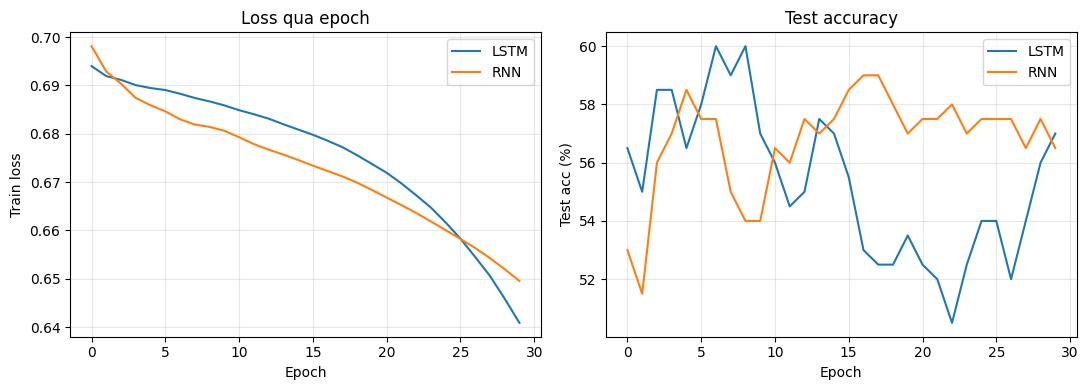

LSTM final test acc: 57.00%
RNN  final test acc: 56.50%

LSTM thường giải quyết bài này; RNN cơ bản với chuỗi 30 thường loanh quanh 50% (đoán mò).


In [7]:
class TokenModel(nn.Module):
    def __init__(self, vocab_size=10, embed_dim=8, hidden_dim=16, cell='lstm'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        if cell == 'lstm':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        else:
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_dim, 2)
        self.cell = cell

    def forward(self, x):
        e = self.embedding(x)
        if self.cell == 'lstm':
            _, (h_n, _) = self.rnn(e)
        else:
            _, h_n = self.rnn(e)
        return self.fc(h_n.squeeze(0))

def train_compare(cell, epochs=30, lr=0.01):
    torch.manual_seed(42)
    m = TokenModel(cell=cell).to(device)
    opt = optim.Adam(m.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    Xt, yt = Xs_train.to(device), ys_train.to(device)
    Xv, yv = Xs_test.to(device),  ys_test.to(device)
    losses, accs = [], []
    for ep in range(epochs):
        m.train()
        opt.zero_grad()
        loss = crit(m(Xt), yt)
        loss.backward()
        opt.step()
        m.eval()
        with torch.no_grad():
            acc = (m(Xv).argmax(1) == yv).float().mean().item()
        losses.append(loss.item()); accs.append(acc)
    return losses, accs

losses_lstm, accs_lstm = train_compare('lstm')
losses_rnn,  accs_rnn  = train_compare('rnn')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(losses_lstm, label='LSTM'); axes[0].plot(losses_rnn, label='RNN')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss qua epoch')
axes[1].plot([a*100 for a in accs_lstm], label='LSTM')
axes[1].plot([a*100 for a in accs_rnn],  label='RNN')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy')
plt.tight_layout(); plt.show()

print(f'LSTM final test acc: {accs_lstm[-1]*100:.2f}%')
print(f'RNN  final test acc: {accs_rnn[-1]*100:.2f}%')
print('\nLSTM thường giải quyết bài này; RNN cơ bản với chuỗi 30 thường loanh quanh 50% (đoán mò).')